# Phase 4 — Base de données interne

Objectif : relier dans une seule base interrogeable les briques construites séparément dans les phases précédentes — gènes (Phase 1), molécules candidates (Phase 2), voie de signalisation (Phase 3) — **et** les enrichir avec une source externe indépendante : **GDSC** (Genomics of Drug Sensitivity in Cancer), qui mesure la sensibilité réelle de lignées cellulaires de cancer du sein à des centaines de médicaments, y compris ceux qui ciblent HER2/PI3K/AKT.

C'est la question posée dans la roadmap initiale : *"pour un sous-type donné, quelles cibles, quelles molécules candidates, quelle voie de signalisation ?"* — plus une validation empirique inattendue : GDSC permet de vérifier, sur des données de laboratoire réelles, si nos hypothèses de modélisation (Phases 2 et 3) sont cohérentes avec la biologie observée.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 1. Récupération et filtrage des données GDSC

Source : [Sanger GDSC bulk download](https://ftp.sanger.ac.uk/pub/project/cancerrxgene/releases/current_release/) (GDSC2, version du 24/07/2022). On filtre sur :
- `TCGA_DESC == 'BRCA'` (lignées de cancer du sein — 51 lignées)
- les médicaments ciblant ERBB2/EGFR/PI3K/AKT (la voie modélisée en Phase 3)

In [2]:
import os
import requests

GDSC_URL = "https://ftp.sanger.ac.uk/pub/project/cancerrxgene/releases/current_release/GDSC2_fitted_dose_response_24Jul22.csv"
GDSC_RAW_PATH = "../data/raw/gdsc/GDSC2_fitted_dose_response_24Jul22.csv"

os.makedirs("../data/raw/gdsc", exist_ok=True)
if not os.path.exists(GDSC_RAW_PATH):
    print("Téléchargement des données GDSC2 (~40 Mo)...")
    resp = requests.get(GDSC_URL, timeout=120)
    resp.raise_for_status()
    with open(GDSC_RAW_PATH, "wb") as f:
        f.write(resp.content)

gdsc_raw = pd.read_csv(GDSC_RAW_PATH)
brca = gdsc_raw[gdsc_raw["TCGA_DESC"] == "BRCA"]
targeted = brca[
    brca["PUTATIVE_TARGET"].astype(str).str.contains("ERBB2|EGFR|PI3K|AKT", case=False, na=False)
][["COSMIC_ID", "CELL_LINE_NAME", "DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME", "LN_IC50", "AUC"]].copy()

print(f"{len(targeted)} mesures dose-réponse | {targeted['CELL_LINE_NAME'].nunique()} lignées | {targeted['DRUG_NAME'].nunique()} médicaments")
targeted.to_csv("../data/raw/gdsc/gdsc_brca_targeted_response.csv", index=False)
targeted.head()

1475 mesures dose-réponse | 51 lignées | 29 médicaments


,COSMIC_ID,CELL_LINE_NAME,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
5376,749709,HCC1954,Gefitinib,EGFR,EGFR signaling,3.480012,0.985315
5377,749710,HCC1143,Gefitinib,EGFR,EGFR signaling,2.835040,0.950233
5378,749711,HCC1187,Gefitinib,EGFR,EGFR signaling,3.531042,0.986127
5379,749712,HCC1395,Gefitinib,EGFR,EGFR signaling,3.871020,0.978491
5380,749713,HCC1599,Gefitinib,EGFR,EGFR signaling,4.403500,0.979077


## 2. Annotation des lignées par sous-type moléculaire

GDSC ne fournit pas le sous-type moléculaire (Luminal/HER2/Triple Négatif) directement — seulement le type de cancer (BRCA). On utilise une classification **manuelle, issue de la littérature** (Neve et al. 2006, *Cancer Cell* ; Kao et al. 2009, *PLoS ONE* — les références standard pour la sous-typisation des lignées de cancer du sein), limitée aux lignées où le consensus de la littérature est net. Les lignées ambiguës ou non documentées restent "Non classé" plutôt que d'être devinées.

In [3]:
# Classification manuelle (littérature), volontairement incomplète : mieux vaut "Non classé"
# qu'une classification devinée pour les lignées moins documentées.
SUBTYPE_MAP = {
    # Luminal A (ER+, HER2-)
    "MCF7": "Luminal A", "T47D": "Luminal A", "CAMA-1": "Luminal A", "HCC1428": "Luminal A",
    "HCC1500": "Luminal A", "MDA-MB-175-VII": "Luminal A", "EFM-19": "Luminal A",
    # HER2-enrichi (ERBB2 amplifié)
    "BT-474": "HER2-enrichi", "AU565": "HER2-enrichi", "HCC1954": "HER2-enrichi",
    "HCC202": "HER2-enrichi", "HCC2218": "HER2-enrichi", "JIMT-1": "HER2-enrichi",
    "MDA-MB-361": "HER2-enrichi", "UACC-893": "HER2-enrichi", "EFM-192A": "HER2-enrichi",
    # Triple Négatif / basal-like (ER-, PR-, HER2-)
    "MDA-MB-231": "Triple Negatif", "MDA-MB-468": "Triple Negatif", "BT-20": "Triple Negatif",
    "HCC1143": "Triple Negatif", "HCC1187": "Triple Negatif", "HCC1937": "Triple Negatif",
    "HCC38": "Triple Negatif", "HCC70": "Triple Negatif", "HCC1599": "Triple Negatif",
    "HCC1395": "Triple Negatif", "Hs-578-T": "Triple Negatif", "BT-549": "Triple Negatif",
    "CAL-51": "Triple Negatif", "CAL-120": "Triple Negatif", "MDA-MB-157": "Triple Negatif",
    "MDA-MB-436": "Triple Negatif", "DU-4475": "Triple Negatif",
}

cell_lines = (
    brca[["COSMIC_ID", "CELL_LINE_NAME"]]
    .drop_duplicates()
    .assign(subtype=lambda d: d["CELL_LINE_NAME"].map(SUBTYPE_MAP).fillna("Non classé"))
)
print(cell_lines["subtype"].value_counts())

subtype
Non classé        18
Triple Negatif    17
HER2-enrichi       9
Luminal A          7
Name: count, dtype: int64


## 3. Construction de la base SQLite

Six tables : `genes` (Phase 1), `pathways` + `pathway_genes` (Phase 3), `subtypes`, `cell_lines` + `drug_response` (GDSC), `molecules` (Phase 2).

In [4]:
conn = sqlite3.connect("../data/processed/molprint.db")

# --- genes (Phase 1) ---
genes = pd.read_csv("../data/processed/gene_sequence_analysis.csv")
genes.to_sql("genes", conn, if_exists="replace", index=False)

# --- subtypes : lien gène clé <-> sous-type, ancré sur les résultats SHAP d'OncoPrint ---
subtypes = pd.DataFrame([
    {"subtype": "Luminal A", "key_gene": "ESR1", "shap_rank": 1},
    {"subtype": "Luminal A", "key_gene": "GATA3", "shap_rank": 5},
    {"subtype": "HER2-enrichi", "key_gene": "ERBB2", "shap_rank": 2},
    {"subtype": "Triple Negatif", "key_gene": "FOXA1", "shap_rank": 4},
    {"subtype": "Triple Negatif", "key_gene": "AR", "shap_rank": 5},
])
subtypes.to_sql("subtypes", conn, if_exists="replace", index=False)

# --- pathways (Phase 3) ---
pathways = pd.DataFrame([{"pathway_name": "HER2/PI3K/AKT", "notebook": "07_systems_biology_her2_pathway.ipynb"}])
pathways.to_sql("pathways", conn, if_exists="replace", index=False)
pathway_genes = pd.DataFrame([
    {"pathway_name": "HER2/PI3K/AKT", "gene": "ERBB2", "role": "récepteur, point d'entrée du signal"},
    {"pathway_name": "HER2/PI3K/AKT", "gene": "PIK3CA", "role": "relai intermédiaire (mutation = résistance documentée)"},
    {"pathway_name": "HER2/PI3K/AKT", "gene": "AKT1", "role": "effecteur final, signal de prolifération"},
])
pathway_genes.to_sql("pathway_genes", conn, if_exists="replace", index=False)

# --- molecules (Phase 2 : candidats criblés) ---
molecules = pd.read_csv("../data/processed/erbb2_candidate_shortlist_with_domain.csv")
molecules["target_gene"] = "ERBB2"
molecules.to_sql("molecules", conn, if_exists="replace", index=False)

# --- cell_lines + drug_response (GDSC) ---
cell_lines.to_sql("cell_lines", conn, if_exists="replace", index=False)
targeted.rename(columns={"CELL_LINE_NAME": "CELL_LINE_NAME"}).to_sql("drug_response", conn, if_exists="replace", index=False)

conn.commit()
print("Tables créées :", [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'")])

Tables créées : ['genes', 'subtypes', 'pathways', 'pathway_genes', 'molecules', 'cell_lines', 'drug_response']


## 4. Requête roadmap : "pour un sous-type donné, quelles cibles, quelles molécules, quelle voie ?"

In [5]:
def subtype_report(subtype_name):
    genes_q = pd.read_sql(
        "SELECT key_gene, shap_rank FROM subtypes WHERE subtype = ? ORDER BY shap_rank",
        conn, params=(subtype_name,),
    )
    key_genes = genes_q["key_gene"].tolist()

    molecules_q = pd.DataFrame()
    if "ERBB2" in key_genes:
        molecules_q = pd.read_sql(
            "SELECT canonical_smiles, activity_probability, applicability_domain "
            "FROM molecules WHERE target_gene = 'ERBB2' ORDER BY activity_probability DESC LIMIT 5",
            conn,
        )

    lines_q = pd.read_sql(
        "SELECT COSMIC_ID, CELL_LINE_NAME FROM cell_lines WHERE subtype = ?", conn, params=(subtype_name,)
    )

    print(f"=== {subtype_name} ===")
    print(f"Gènes clés (SHAP OncoPrint) : {key_genes}")
    print(f"Voie de signalisation modélisée : HER2/PI3K/AKT (Phase 3)" if "ERBB2" in key_genes else "Pas de voie modélisée pour ce sous-type")
    print(f"Molécules candidates (MolPrint, cible ERBB2) : {len(molecules_q)} trouvées")
    print(f"Lignées cellulaires GDSC de ce sous-type : {len(lines_q)}")
    return {"key_genes": key_genes, "molecules": molecules_q, "cell_lines": lines_q}

_ = subtype_report("Triple Negatif")

=== Triple Negatif ===
Gènes clés (SHAP OncoPrint) : ['FOXA1', 'AR']
Pas de voie modélisée pour ce sous-type
Molécules candidates (MolPrint, cible ERBB2) : 0 trouvées
Lignées cellulaires GDSC de ce sous-type : 17


In [6]:
result_her2 = subtype_report("HER2-enrichi")
result_her2["molecules"]

=== HER2-enrichi ===
Gènes clés (SHAP OncoPrint) : ['ERBB2']
Voie de signalisation modélisée : HER2/PI3K/AKT (Phase 3)
Molécules candidates (MolPrint, cible ERBB2) : 5 trouvées
Lignées cellulaires GDSC de ce sous-type : 9


,canonical_smiles,activity_probability,applicability_domain
0,Cn1cnc2cc(Nc3ncnc4ccc(N5CCN(c6ccn7ncnc7c6)CC5)...,0.982810,modérément nouveau
1,c1nc(Nc2ccn3ncnc3c2)c2nc(N3CCN(c4ccn5ncnc5c4)C...,0.973426,modérément nouveau
2,Cn1cnc2cc(Nc3ccc4ncnc(N5CCN(c6ccn7ncnc7c6)CC5)...,0.944849,modérément nouveau
3,COc1ncnc2cc(-c3ccc4c(c3)ncn4C)c(N3CCN(c4ccn5nc...,0.940282,modérément nouveau
4,COc1cc2ncnc(-c3ccn4ncnc4c3)c2nc1N1CCN(c2ccn3nc...,0.934029,modérément nouveau


## 5. Validation empirique : le lapatinib est-il vraiment plus efficace en HER2-enrichi ?

GDSC mesure la sensibilité réelle (en laboratoire) de dizaines de lignées cellulaires à des centaines de médicaments — indépendamment de tout ce qu'on a modélisé en Phases 2 et 3. On peut donc vérifier si nos hypothèses (lapatinib cible HER2, la voie HER2/PI3K/AKT est le moteur du sous-type HER2-enrichi) sont cohérentes avec des données de laboratoire réelles.

                    mean  count
subtype                        
HER2-enrichi    0.589288      8
Luminal A       2.847628      7
Triple Negatif  3.061018     17


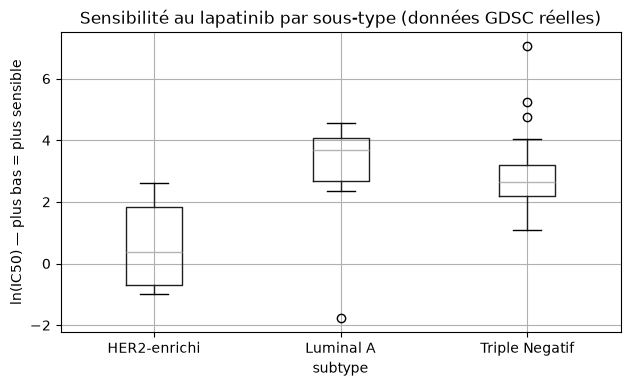

In [7]:
lapatinib_by_subtype = pd.read_sql(
    '''
    SELECT c.subtype, r.LN_IC50
    FROM drug_response r
    JOIN cell_lines c ON r.COSMIC_ID = c.COSMIC_ID
    WHERE r.DRUG_NAME = 'Lapatinib' AND c.subtype != 'Non classé'
    ''',
    conn,
)

summary = lapatinib_by_subtype.groupby("subtype")["LN_IC50"].agg(["mean", "count"])
print(summary)

lapatinib_by_subtype.boxplot(column="LN_IC50", by="subtype", figsize=(7, 4))
plt.ylabel("ln(IC50) — plus bas = plus sensible")
plt.title("Sensibilité au lapatinib par sous-type (données GDSC réelles)")
plt.suptitle("")
plt.show()

**Résultat** : les lignées HER2-enrichi sont nettement plus sensibles au lapatinib (ln(IC50) le plus bas) que les lignées Luminal A ou Triple Négatif — cohérent avec le fait que le lapatinib cible spécifiquement HER2, et avec la voie modélisée en Phase 3. C'est une confirmation indépendante (données de laboratoire réelles, pas un artefact de nos modèles) que la logique du projet tient debout.

In [8]:
conn.close()
print("Base sauvegardée : data/processed/molprint.db")

Base sauvegardée : data/processed/molprint.db
